# 02 Index Construction
**Climate Risk Exposure Index**

Builds a composite physical-hazard exposure index for 21 countries following the four-step OECD/JRC composite-indicator method:
1. Indicator selection (done in notebook 01)
2. Normalisation (min-max, 0–1)
3. Weighting (equal weights as transparent default)
4. Aggregation → composite score → ranking

Also includes driver decomposition and sensitivity analysis.

## 1. Libraries loading and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Colour palette ──────────────────────────────────────────────────────────
C = {
    'temperature':   '#E63946',
    'precipitation': '#4361EE',
    'drought':       '#F4A261',
    'composite':     '#1D3557',
    'low_risk':      '#2DC653',
    'high_risk':     '#E63946',
    'bg':            '#F8F9FA',
    'grid':          '#DEE2E6',
    'text':          '#212529',
}

HAZARD_COLORS = [C['temperature'], C['precipitation'], C['drought']]

plt.rcParams.update({
    'figure.facecolor':  C['bg'],
    'axes.facecolor':    C['bg'],
    'axes.edgecolor':    C['grid'],
    'axes.grid':         True,
    'grid.color':        C['grid'],
    'grid.linewidth':    0.7,
    'text.color':        C['text'],
    'axes.labelcolor':   C['text'],
    'xtick.color':       C['text'],
    'ytick.color':       C['text'],
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        130,
})

PANEL_PATH  = Path('cckp_raw/exposure_panel.csv')
OUTPUT_DIR  = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

INDICATORS = ['temperature', 'precipitation', 'drought']

In [2]:
panel = pd.read_csv(PANEL_PATH)
panel

,country,year,temperature,precipitation,drought
0,Australia,2000,39.43,74.93,88.93
1,Australia,2001,41.26,65.20,76.13
2,Australia,2002,41.03,63.27,135.38
3,Australia,2003,41.38,68.46,78.44
4,Australia,2004,40.75,52.58,87.17
...,...,...,...,...,...
499,United States,2019,33.30,48.69,27.51
500,United States,2020,33.18,41.17,34.33
501,United States,2021,33.65,45.17,30.83
502,United States,2022,34.15,40.03,31.70


## 1. Aggregation of indicator per county over time

In [3]:
print(f"Panel: {panel.shape}  ({panel['year'].min()}–{panel['year'].max()})")
print()
# Average each indicator across 2000–2023 → one value per country per hazard
cross = panel.groupby('country')[INDICATORS].mean().reset_index()
cross = cross.sort_values('country').reset_index(drop=True)

print(f"There are {len(cross)} countries in total:")
cross.round(2)

Panel: (504, 5)  (2000–2023)

There are 21 countries in total:


,country,temperature,precipitation,drought
0,Australia,41.19,61.49,87.78
1,Belgium,32.51,54.40,17.91
2,Brazil,35.67,88.59,50.97
3,Denmark,26.92,47.00,18.80
4,France,33.31,55.49,19.83
5,Germany,32.83,50.26,17.51
6,Greece,34.60,72.78,42.65
7,India,39.48,127.13,68.80
8,Ireland,24.33,58.93,16.60
9,Italy,32.67,76.48,28.24


## 2. Indicator Normalisation (Min-max approach)
### 0 = least exposed, 1 = most exposed

In [4]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

norm = cross.copy()
for ind in INDICATORS:
    norm[ind] = minmax(cross[ind])

print("Normalised indicators (0–1):")
norm.round(3)

Normalised indicators (0–1):


,country,temperature,precipitation,drought
0,Australia,1.000,0.227,1.000
1,Belgium,0.496,0.144,0.023
2,Brazil,0.679,0.546,0.486
3,Denmark,0.171,0.057,0.036
4,France,0.542,0.157,0.050
5,Germany,0.514,0.095,0.018
6,Greece,0.617,0.360,0.369
7,India,0.901,1.000,0.735
8,Ireland,0.020,0.197,0.005
9,Italy,0.504,0.404,0.168


## 3. Indicators weighting & aggregation → composite score

In [5]:
# Equal weights (transparent default; tested against alternatives in sensitivity analysis)
WEIGHTS = {
    'temperature':   1/3,
    'precipitation': 1/3,
    'drought':       1/3,
}

scored = norm.copy()
scored['composite'] = sum(scored[ind] * w for ind, w in WEIGHTS.items())
scored = scored.sort_values('composite', ascending=False).reset_index(drop=True)
scored.insert(0, 'rank', scored.index + 1)

print("Final ranking:")
scored[['rank', 'country', 'composite'] + INDICATORS].round(3)

Final ranking:


,rank,country,composite,temperature,precipitation,drought
0,1,India,0.878,0.901,1.000,0.735
1,2,Nigeria,0.785,0.897,0.509,0.948
2,3,Australia,0.742,1.000,0.227,1.000
3,4,Portugal,0.575,0.720,0.533,0.471
4,5,Brazil,0.570,0.679,0.546,0.486
5,6,Kenya,0.564,0.667,0.204,0.820
6,7,South Africa,0.479,0.720,0.091,0.625
7,8,Greece,0.449,0.617,0.360,0.369
8,9,Spain,0.393,0.683,0.145,0.350
9,10,Italy,0.359,0.504,0.404,0.168


## 4. Result visualisation

## i. Composite Exposure Score Ranking

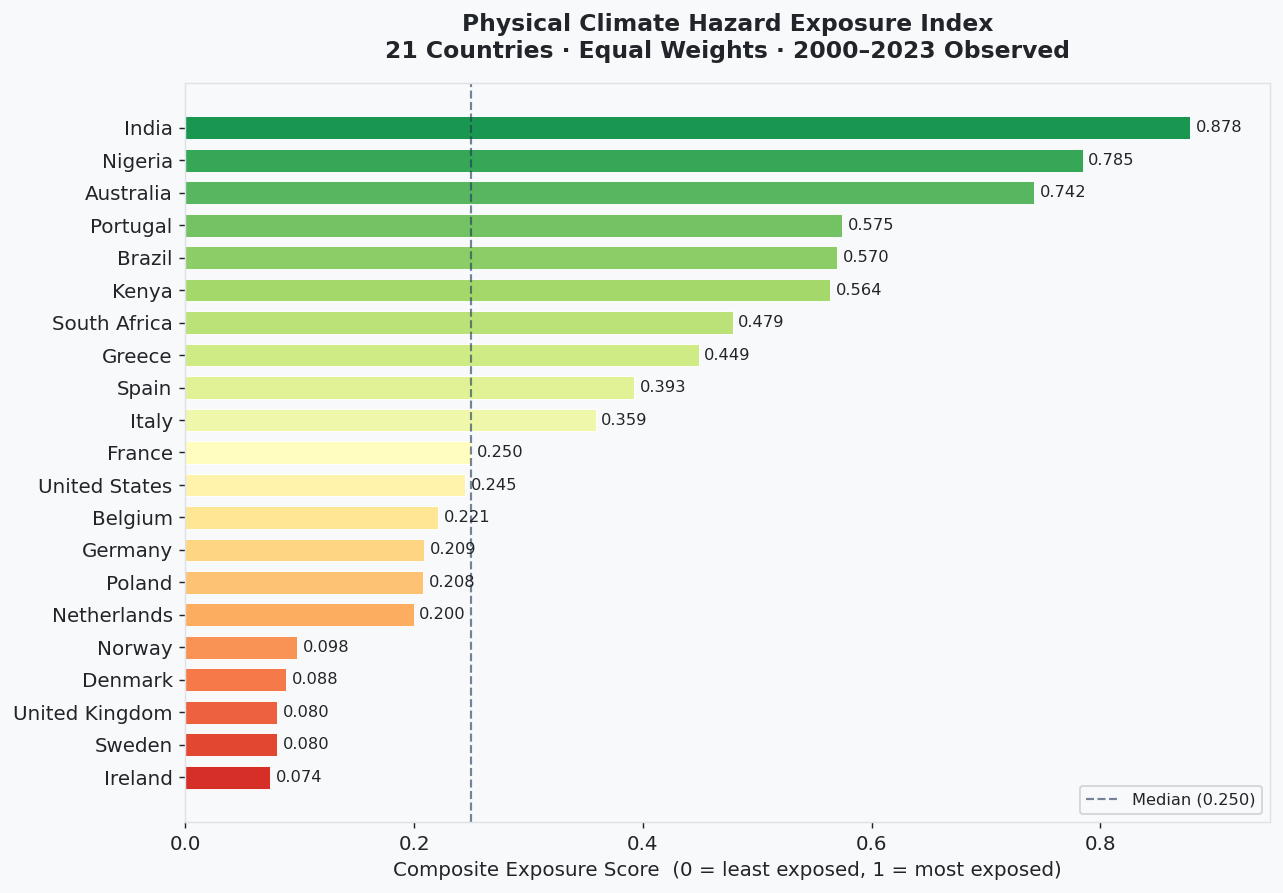

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

n = len(scored)
# Gradient: most exposed = vivid red, least exposed = vivid green
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, n))

bars = ax.barh(
    scored['country'][::-1],
    scored['composite'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.7,
)

# Value labels
for bar, val in zip(bars, scored['composite'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=9, color=C['text'])

ax.set_xlabel('Composite Exposure Score  (0 = least exposed, 1 = most exposed)', fontsize=11)
ax.set_title('Physical Climate Hazard Exposure Index\n21 Countries · Equal Weights · 2000–2023 Observed', pad=14)
ax.set_xlim(0, scored['composite'].max() + 0.07)
ax.axvline(scored['composite'].median(), color=C['composite'], linewidth=1.2,
           linestyle='--', alpha=0.6, label=f"Median ({scored['composite'].median():.3f})")
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_composite_score.png', dpi=150, bbox_inches='tight')
plt.show()

## ii. Heatmap of Normalised Hazard Indicators

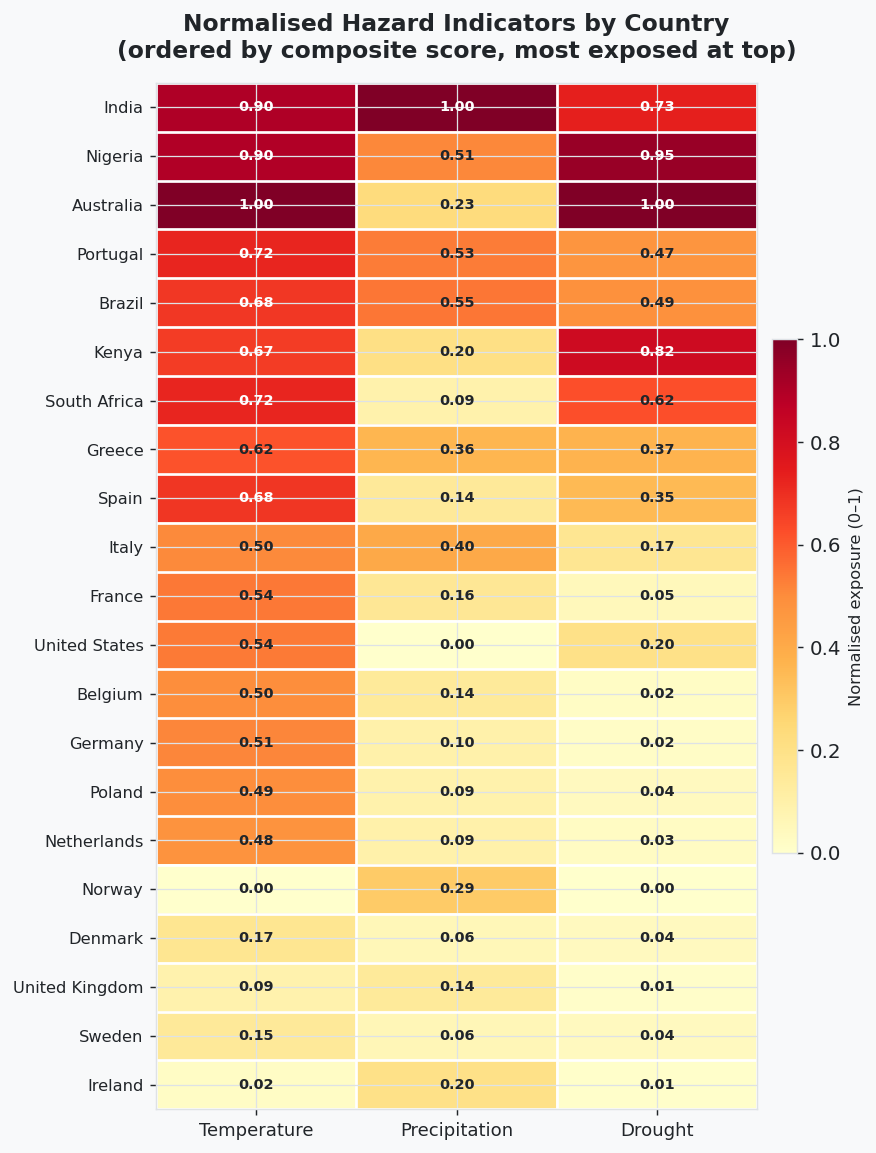

In [7]:
# Order countries by composite score (most exposed at top)
heat_data = norm.set_index('country').loc[scored['country'], INDICATORS].values
countries_ordered = scored['country'].tolist()

fig, ax = plt.subplots(figsize=(7, 9))

im = ax.imshow(heat_data, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')

# Annotate each cell
for i in range(len(countries_ordered)):
    for j in range(len(INDICATORS)):
        val = heat_data[i, j]
        text_color = 'white' if val > 0.65 else C['text']
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=text_color, fontweight='bold')

ax.set_xticks(range(len(INDICATORS)))
ax.set_xticklabels(['Temperature', 'Precipitation', 'Drought'], fontsize=10)
ax.set_yticks(range(len(countries_ordered)))
ax.set_yticklabels(countries_ordered, fontsize=9)

# White grid lines between cells
ax.set_xticks(np.arange(-0.5, len(INDICATORS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(countries_ordered), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Normalised exposure (0–1)', fontsize=9)

ax.set_title('Normalised Hazard Indicators by Country\n(ordered by composite score, most exposed at top)', pad=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## iii. Driver Decomposition (what drives each country's score?)

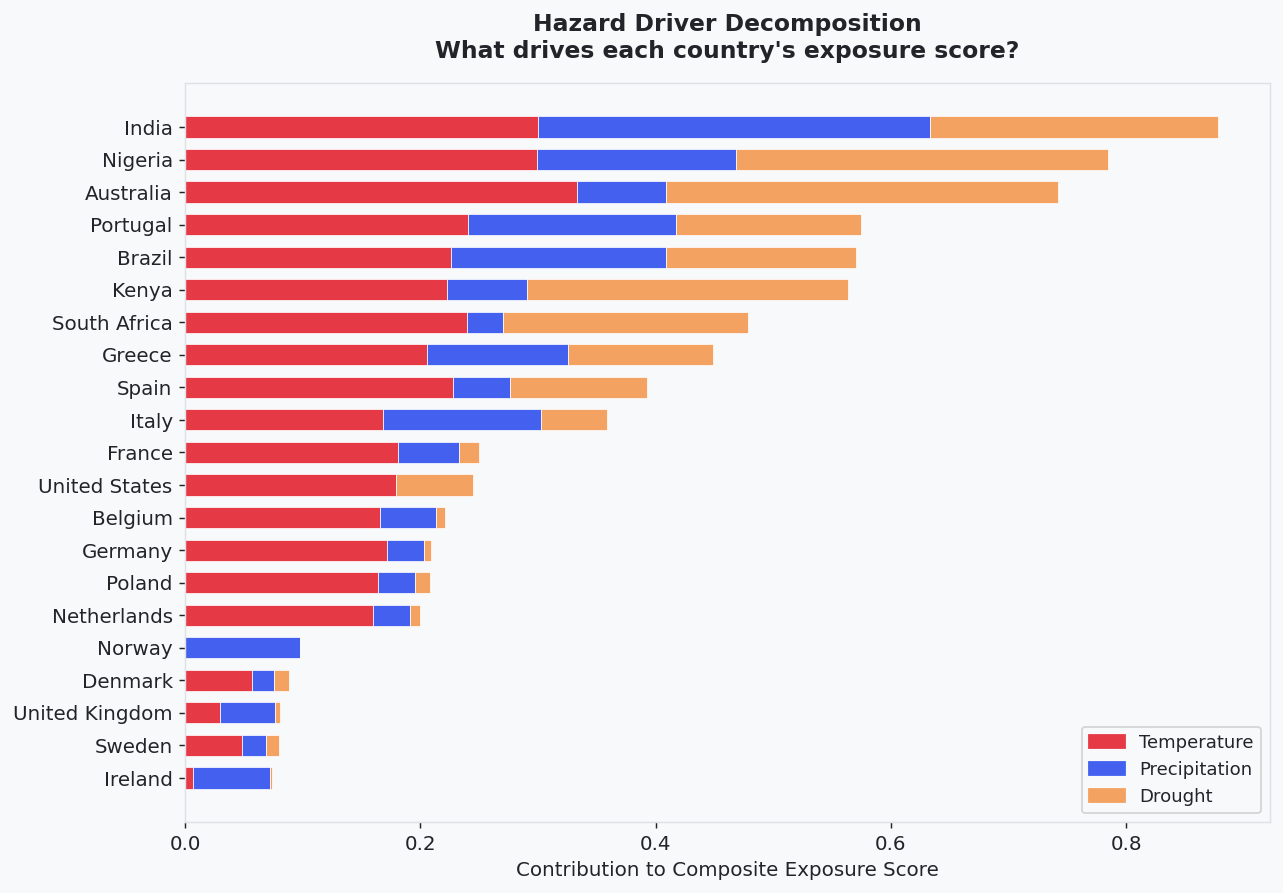

In [8]:
# Contribution of each hazard to the composite score
decomp = scored.set_index('country')[INDICATORS].multiply(
    pd.Series(WEIGHTS)
).loc[scored['country']]

fig, ax = plt.subplots(figsize=(10, 7))

countries = decomp.index.tolist()[::-1]   # lowest rank at top
temp_vals  = decomp['temperature'].values[::-1]
prec_vals  = decomp['precipitation'].values[::-1]
drou_vals  = decomp['drought'].values[::-1]

ax.barh(countries, temp_vals, color=C['temperature'], label='Temperature',   height=0.65, edgecolor='white', linewidth=0.4)
ax.barh(countries, prec_vals, left=temp_vals, color=C['precipitation'], label='Precipitation', height=0.65, edgecolor='white', linewidth=0.4)
ax.barh(countries, drou_vals, left=temp_vals + prec_vals, color=C['drought'], label='Drought', height=0.65, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Contribution to Composite Exposure Score', fontsize=11)
ax.set_title('Hazard Driver Decomposition\nWhat drives each country\'s exposure score?', pad=14)
ax.legend(loc='lower right', fontsize=10,
          handles=[
              mpatches.Patch(color=C['temperature'],   label='Temperature'),
              mpatches.Patch(color=C['precipitation'], label='Precipitation'),
              mpatches.Patch(color=C['drought'],       label='Drought'),
          ])
ax.grid(axis='y', alpha=0)
ax.grid(axis='x')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_driver_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sensitivity Analysis
## i. Does the ranking hold under different weights?
Tests 5 weighting schemes. A stable ranking across schemes = robust finding.

In [9]:
WEIGHT_SCHEMES = {
    'Equal (1/3 each)':          {'temperature': 1/3,  'precipitation': 1/3,  'drought': 1/3},
    'Temperature-heavy (½)':     {'temperature': 0.50, 'precipitation': 0.25, 'drought': 0.25},
    'Precipitation-heavy (½)':   {'temperature': 0.25, 'precipitation': 0.50, 'drought': 0.25},
    'Drought-heavy (½)':         {'temperature': 0.25, 'precipitation': 0.25, 'drought': 0.50},
    'No drought (½ + ½)':        {'temperature': 0.50, 'precipitation': 0.50, 'drought': 0.00},
}

SCHEME_COLORS = ['#1D3557', '#E63946', '#4361EE', '#F4A261', '#2DC653']

rank_results = {}
for scheme, weights in WEIGHT_SCHEMES.items():
    s = norm.copy()
    s['composite'] = sum(s[ind] * w for ind, w in weights.items())
    s = s.sort_values('composite', ascending=False).reset_index(drop=True)
    s['rank'] = s.index + 1
    rank_results[scheme] = s.set_index('country')['rank']

rank_df = pd.DataFrame(rank_results)
print("Rank under each weighting scheme:")
rank_df

Rank under each weighting scheme:


,Equal (1/3 each),Temperature-heavy (½),Precipitation-heavy (½),Drought-heavy (½),No drought (½ + ½)
country,,,,,
Australia,3,3,3,3,4
Belgium,13,13,12,13,12
Brazil,5,5,4,5,5
Denmark,18,17,20,17,19
France,11,11,11,12,11
Germany,14,14,14,15,13
Greece,8,8,7,8,6
India,1,1,1,1,1
Ireland,21,21,18,21,20


## ii. Rank Stability Across Weight Schemes

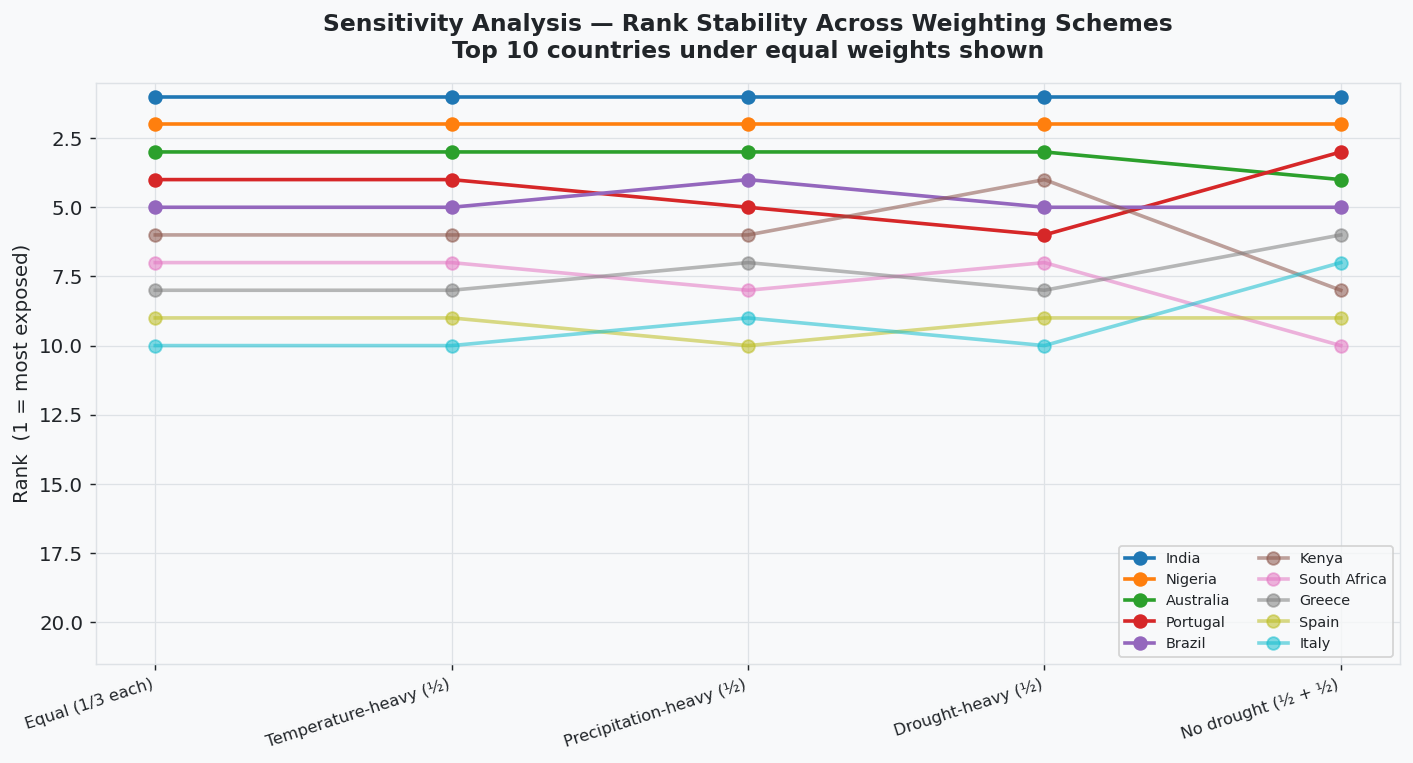

In [10]:
# Focus on top 10 most-exposed countries under equal weights
top10 = scored['country'].head(10).tolist()
plot_df = rank_df.loc[top10]

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(WEIGHT_SCHEMES))
for i, country in enumerate(top10):
    ranks = plot_df.loc[country].values
    alpha = 1.0 if i < 5 else 0.55
    ax.plot(x, ranks, marker='o', linewidth=2, markersize=7,
            label=country, alpha=alpha)

ax.set_xticks(x)
ax.set_xticklabels(list(WEIGHT_SCHEMES.keys()), rotation=18, ha='right', fontsize=9)
ax.invert_yaxis()   # rank 1 at top
ax.set_ylabel('Rank  (1 = most exposed)', fontsize=11)
ax.set_title('Sensitivity Analysis — Rank Stability Across Weighting Schemes\nTop 10 countries under equal weights shown', pad=14)
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.set_ylim(len(scored) + 0.5, 0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## iii. Scatter: Temperature vs Drought (methodology context)

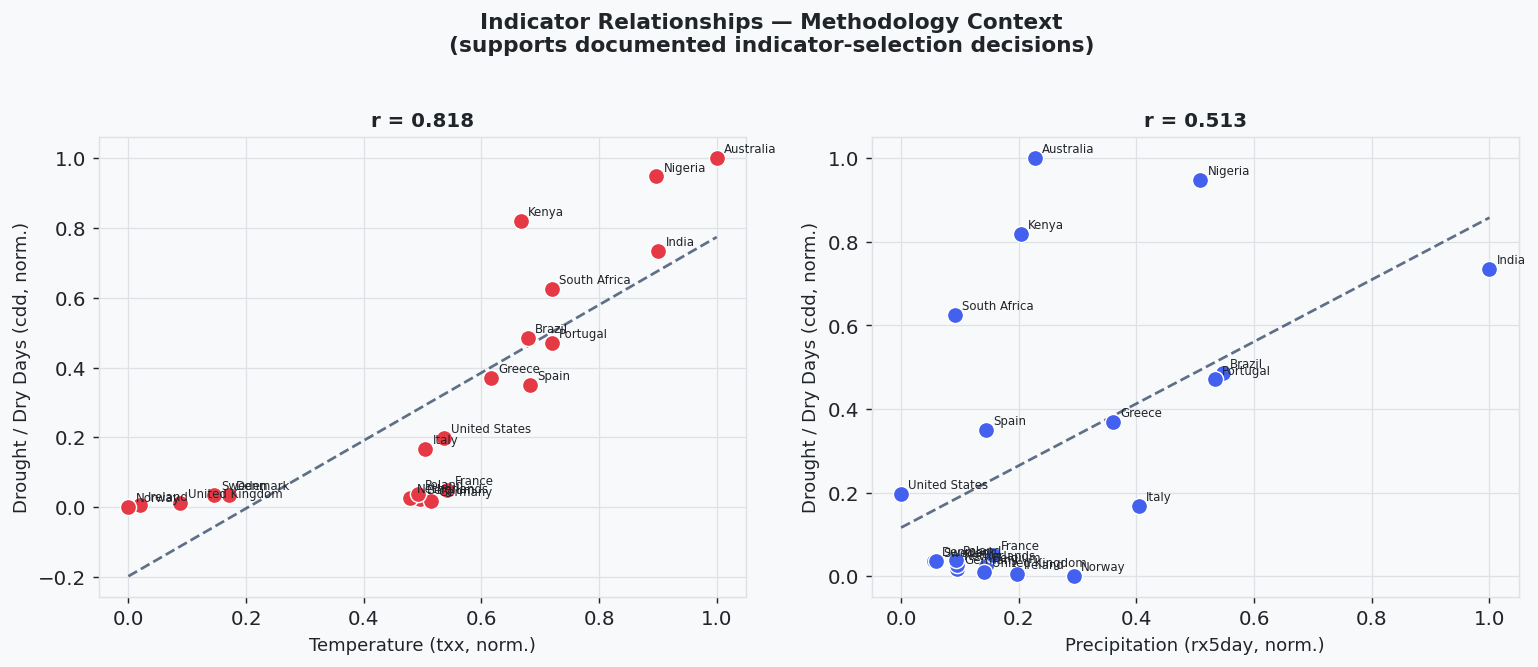

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_pairs = [
    ('temperature', 'drought',       C['temperature'], C['drought']),
    ('precipitation', 'drought',     C['precipitation'], C['drought']),
]

labels = {'temperature': 'Temperature (txx, norm.)',
          'precipitation': 'Precipitation (rx5day, norm.)',
          'drought': 'Drought / Dry Days (cdd, norm.)'}

for ax, (x_var, y_var, cx, cy) in zip(axes, scatter_pairs):
    x = norm[x_var]
    y = norm[y_var]
    r = np.corrcoef(x, y)[0, 1]

    ax.scatter(x, y, color=cx, s=80, edgecolors='white', linewidth=0.8, zorder=3)

    # Label each point
    for _, row in norm.iterrows():
        ax.annotate(row['country'], (row[x_var], row[y_var]),
                    fontsize=6.5, color=C['text'],
                    xytext=(4, 3), textcoords='offset points')

    # Trend line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color=C['composite'],
            linewidth=1.5, linestyle='--', alpha=0.7)

    ax.set_xlabel(labels[x_var], fontsize=10)
    ax.set_ylabel(labels[y_var], fontsize=10)
    ax.set_title(f'r = {r:.3f}', fontsize=11)

fig.suptitle('Indicator Relationships — Methodology Context\n(supports documented indicator-selection decisions)',
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_scatter_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## iv. Time Trend: How has exposure shifted 2000–2023?

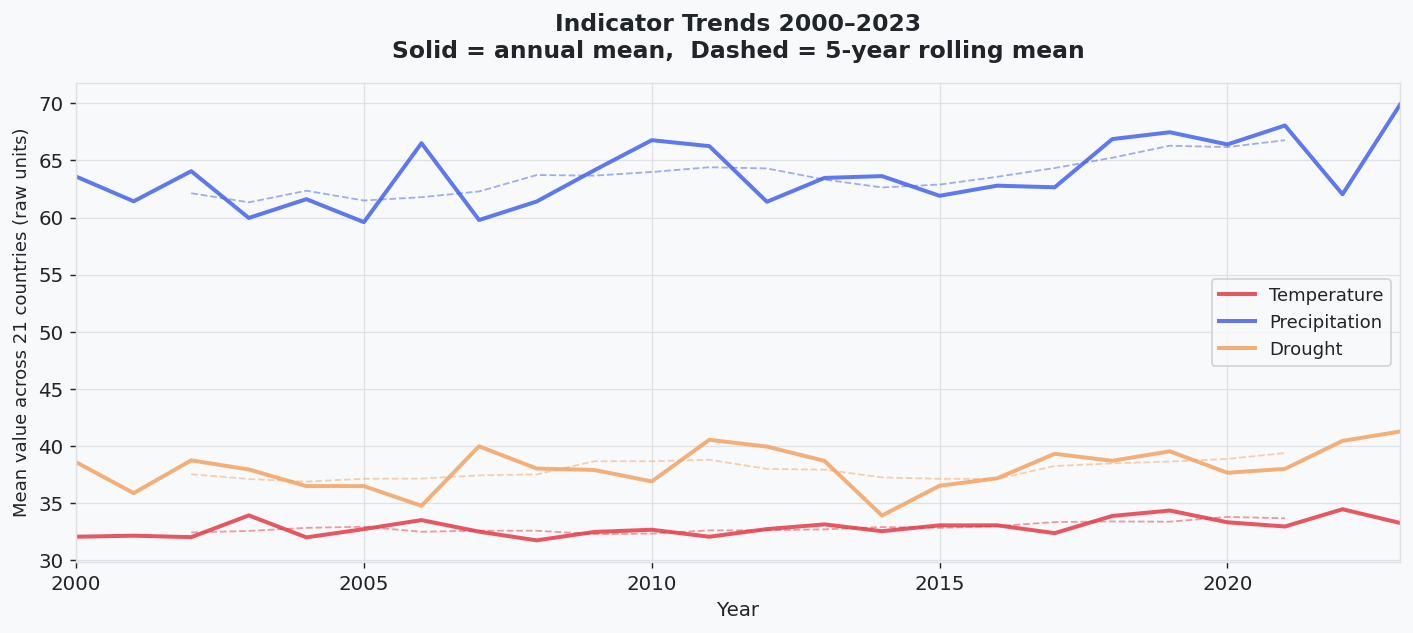

In [13]:
# 5-year rolling mean of each indicator across all 21 countries (global average)
trend = panel.groupby('year')[INDICATORS].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

for ind, color in zip(INDICATORS, HAZARD_COLORS):
    ax.plot(trend['year'], trend[ind], color=color, linewidth=2.2,
            label=ind.capitalize(), alpha=0.85)
    # Rolling mean overlay
    roll = trend[ind].rolling(5, center=True).mean()
    ax.plot(trend['year'], roll, color=color, linewidth=1,
            linestyle='--', alpha=0.5)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean value across 21 countries (raw units)', fontsize=10)
ax.set_title('Indicator Trends 2000–2023\nSolid = annual mean,  Dashed = 5-year rolling mean', pad=14)
ax.legend(fontsize=10)
ax.set_xlim(2000, 2023)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Final Results Table

In [14]:
results = scored[['rank', 'country', 'composite'] + INDICATORS].copy()
results.columns = ['Rank', 'Country', 'Composite Score',
                   'Temperature (norm.)', 'Precipitation (norm.)', 'Drought (norm.)']
results = results.round(3)

results.to_csv(OUTPUT_DIR / 'exposure_index_results.csv', index=False)
print(f"Saved → {OUTPUT_DIR / 'exposure_index_results.csv'}")
print()
print(results.to_string(index=False))

Saved → outputs\exposure_index_results.csv

 Rank        Country  Composite Score  Temperature (norm.)  Precipitation (norm.)  Drought (norm.)
    1          India            0.878                0.901                  1.000            0.735
    2        Nigeria            0.785                0.897                  0.509            0.948
    3      Australia            0.742                1.000                  0.227            1.000
    4       Portugal            0.575                0.720                  0.533            0.471
    5         Brazil            0.570                0.679                  0.546            0.486
    6          Kenya            0.564                0.667                  0.204            0.820
    7   South Africa            0.479                0.720                  0.091            0.625
    8         Greece            0.449                0.617                  0.360            0.369
    9          Spain            0.393                0.683       